# Evaluation, Grad-CAM, and Error Analysis

A high accuracy score on a balanced binary task is a weak result on its own. It cannot
distinguish a model that recognizes animals from one that has latched onto a spurious
correlation (indoor-vs-outdoor backgrounds, say, or the presence of a collar), and it
says nothing about which images remain hard.

This notebook attacks both questions:

* **Per-class precision, recall, and F1**, plus a confusion matrix, to see whether errors are symmetric or the model systematically favors one class.
* **Grad-CAM**, to visualize which image regions actually drive each prediction. This is the single most informative addition here: it is the difference between reporting that a model works and showing *why* it works.
* **Error analysis on the most confidently wrong predictions**, which is where mislabeled and genuinely ambiguous images surface.

Everything below uses the best checkpoint from notebook 02 and the held-out **test**
split from notebook 01, which is the one set of images that has been touched by
neither training nor checkpoint selection. Notebook 02 chose its checkpoint by
validation loss, so the validation score is a maximum taken over every epoch and is
biased upward. The numbers below are not.

## Imports and setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from catsdogs.dataset import IMAGENET_MEAN, IMAGENET_STD, CatsDogsDataset, build_transforms
from catsdogs.evaluate import (
    compute_confusion_matrix,
    most_confident_errors,
    per_class_metrics,
    predict_probabilities,
)
from catsdogs.gradcam import GradCAM, overlay_heatmap
from catsdogs.model import build_model

CLASS_NAMES = ["cat", "dog"]
PROCESSED_DIR = Path("../data/processed")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The model is rebuilt with `pretrained=False` before loading the checkpoint, since there
is no sense downloading ImageNet weights only to immediately overwrite them with our
fine-tuned ones. The evaluation transform is deterministic, which matters here: Grad-CAM
and the error analysis both need the *same* image every time they index into the
dataset.

In [2]:
model = build_model(num_classes=2, pretrained=False)
model.load_state_dict(torch.load("../outputs/checkpoints/best.pt", map_location=device))
model.to(device)

test_df = pd.read_csv(PROCESSED_DIR / "test_split.csv")
test_paths = [Path(p) for p in test_df["path"]]
test_labels = np.array(test_df["label"])

test_dataset = CatsDogsDataset(test_paths, list(test_labels), build_transforms(train=False))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"evaluating on {len(test_dataset)} held-out images")

evaluating on 3744 held-out images


## Metrics

`predict_probabilities` returns softmax outputs rather than hard labels. Keeping the
probabilities is what makes the error analysis at the end possible: ranking mistakes by
confidence requires knowing how confident the model was, which `argmax` discards.

On a balanced dataset, accuracy, macro precision, and macro recall will be close
together. The per-class breakdown is the informative part: a precision/recall imbalance
*within* a class means the model has an asymmetric bias, mistaking one class for the
other more readily than the reverse.

In [3]:
probs = predict_probabilities(model, test_loader, device)
preds = probs.argmax(axis=1)

accuracy = (preds == test_labels).mean()
print(f"accuracy: {accuracy:.4f}")

pd.DataFrame(per_class_metrics(test_labels, preds), index=CLASS_NAMES).round(4)

accuracy: 0.9882


,precision,recall,f1
cat,0.9893,0.9872,0.9882
dog,0.9872,0.9893,0.9883


## Confusion matrix

With only two classes the confusion matrix holds four numbers, but it answers a question
the metrics table does not pose directly: are the off-diagonal counts balanced?

Roughly equal off-diagonals mean the model is simply wrong occasionally. A lopsided
matrix, with many more cats called dogs than the reverse, points to a systematic bias,
and since notebook 01 confirmed the classes are balanced and the split was stratified,
such a bias could not be blamed on the data distribution.

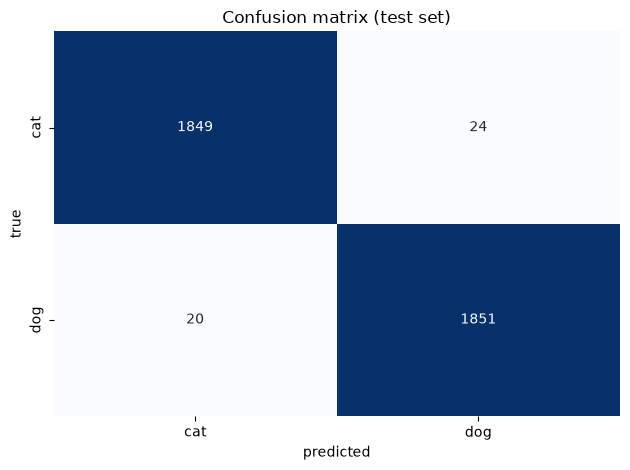

cats misread as dogs: 24
dogs misread as cats: 20


In [4]:
cm = compute_confusion_matrix(test_labels, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=False,
)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix.png", dpi=150)
plt.show()

print(f"cats misread as dogs: {cm[0, 1]}")
print(f"dogs misread as cats: {cm[1, 0]}")

## Grad-CAM: what is the model looking at?

Grad-CAM (Gradient-weighted Class Activation Mapping) answers a question metrics cannot:
*which pixels mattered?*

The mechanism is short enough to state precisely. Take the score for the predicted class
and backpropagate it to the final convolutional block's activation maps. Average each
channel's gradient spatially. That average is how much the class score would change if
that channel were more active, so it serves as the channel's importance weight. Sum the
activation maps weighted by those importances, discard negative contributions with a
ReLU, and upsample the result to the input size. Regions that survive are the regions
that pushed the prediction toward the chosen class.

`src/catsdogs/gradcam.py` implements this directly with forward and backward hooks
rather than pulling in a Grad-CAM library. For a case study the implementation *is* part
of the demonstration, and it keeps the dependency list short.

One honest caveat about resolution: `layer4` outputs a 7x7 spatial grid for a 224x224
input, so each heatmap cell covers a 32x32 pixel region. These maps localize to "the
animal's head" but never to fine detail, and the smooth blobs are an artifact of
bilinear upsampling, not evidence of smooth attention. Reading them as precise pixel
attributions would be overinterpreting.

In [5]:
cam = GradCAM(model, model.layer4[-1])


def to_display_image(tensor: torch.Tensor) -> np.ndarray:
    """Undo ImageNet normalization so a tensor can be shown as an image."""
    array = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(array * IMAGENET_STD + IMAGENET_MEAN, 0, 1)


def label_text(idx: int) -> str:
    return (
        f"true={CLASS_NAMES[test_labels[idx]]}, "
        f"pred={CLASS_NAMES[preds[idx]]} ({probs[idx, preds[idx]]:.2f})"
    )

Correct predictions first, as a baseline for what healthy attention looks like. Expect
the heat to concentrate on the animal, typically the face, rather than on background. If
it consistently landed on furniture, grass, or image borders, high accuracy would be a
warning sign rather than a success: the model would be exploiting dataset artifacts that
will not survive contact with new photographs.

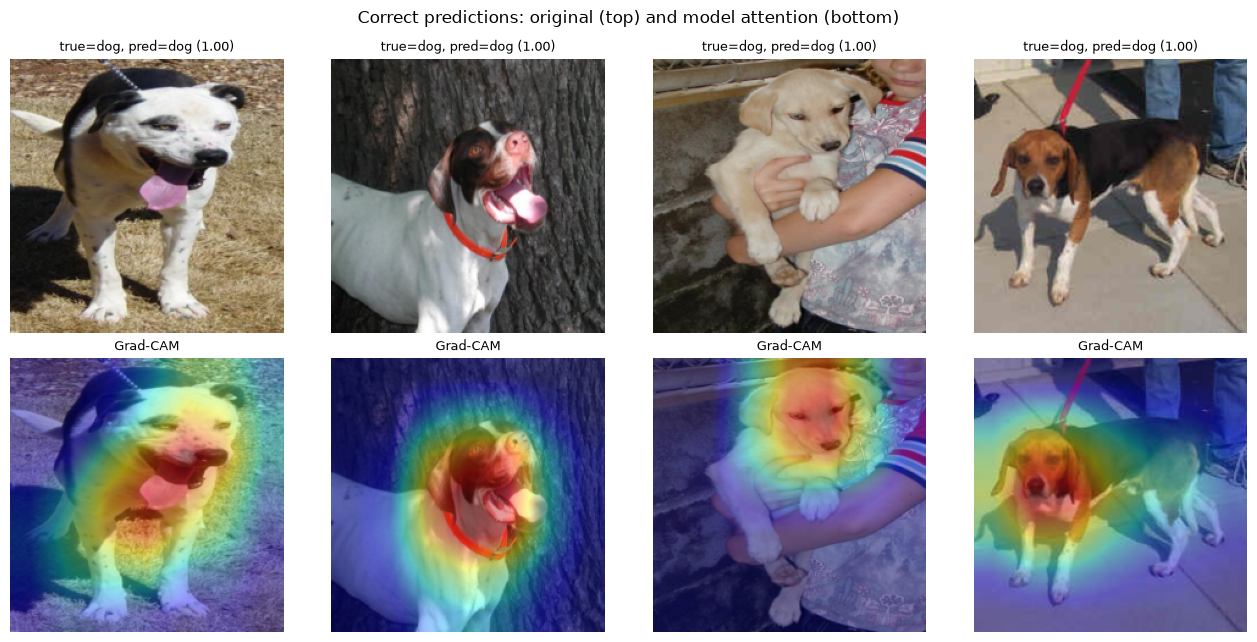

In [6]:
correct_idx = np.flatnonzero(preds == test_labels)[:4]

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for col, idx in enumerate(correct_idx):
    image = test_dataset[idx][0].unsqueeze(0).to(device)
    display = to_display_image(image)
    heatmap = cam(image, target_class=int(preds[idx]))

    axes[0, col].imshow(display)
    axes[0, col].set_title(label_text(idx), fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(display, heatmap))
    axes[1, col].set_title("Grad-CAM", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Correct predictions: original (top) and model attention (bottom)")
plt.tight_layout()
plt.savefig("../outputs/figures/gradcam_correct.png", dpi=150)
plt.show()

Now the same treatment for mistakes. These are the more interesting maps, because they
separate two very different kinds of failure: the model looked at the right subject and
still misjudged it, or it looked somewhere unhelpful entirely. Only the second is really
an attention problem, and the distinction is invisible to any metric.

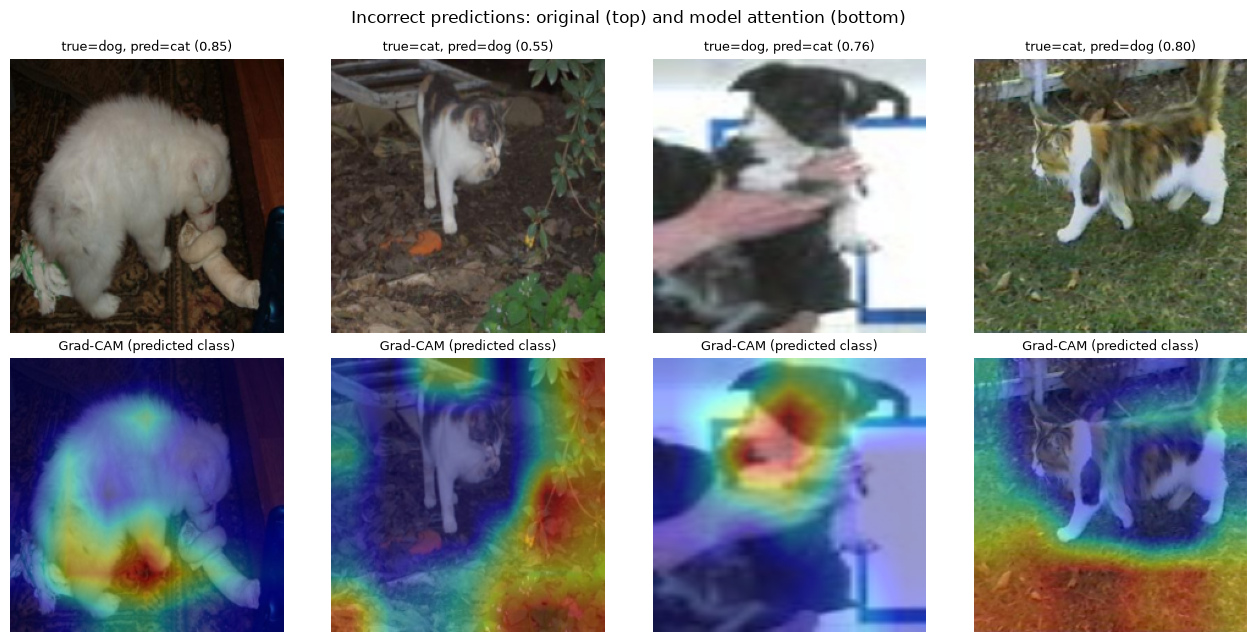

In [7]:
wrong_idx = np.flatnonzero(preds != test_labels)[:4]

fig, axes = plt.subplots(2, len(wrong_idx), figsize=(13, 6.5))
for col, idx in enumerate(wrong_idx):
    image = test_dataset[idx][0].unsqueeze(0).to(device)
    display = to_display_image(image)
    heatmap = cam(image, target_class=int(preds[idx]))

    axes[0, col].imshow(display)
    axes[0, col].set_title(label_text(idx), fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(display, heatmap))
    axes[1, col].set_title("Grad-CAM (predicted class)", fontsize=9)
    axes[1, col].axis("off")

fig.suptitle("Incorrect predictions: original (top) and model attention (bottom)")
plt.tight_layout()
plt.savefig("../outputs/figures/gradcam_incorrect.png", dpi=150)
plt.show()

## Error analysis: the most confidently wrong predictions

Not all mistakes are equally informative. An image the model called a dog with 51%
confidence is a coin flip near the decision boundary and tells us little. An image it
called a dog with 99% confidence *and got wrong* is a real failure of the learned
representation, or a mislabeled file.

`most_confident_errors` ranks misclassified examples by the probability assigned to
the wrong class, surfacing the worst cases first. This is the cell to read closely,
because a web-scraped dataset of this kind tends to hide a few pathological images
in the tail: frames containing both a cat and a dog, animals barely visible in the
shot, and occasionally files that are not animal photographs at all. Whether any of
those actually appear here is exactly what the figure below settles.

Each image is shown with its attention map underneath, because the two questions are
only worth asking together. Knowing that the model was 99% sure and wrong says
nothing about *why*; the map separates a confident misreading of the animal from a
confident reading of something that is not the animal at all. The map is computed for
the class the model chose, not the correct one, so it shows the evidence the model
believed it had rather than the evidence it missed.

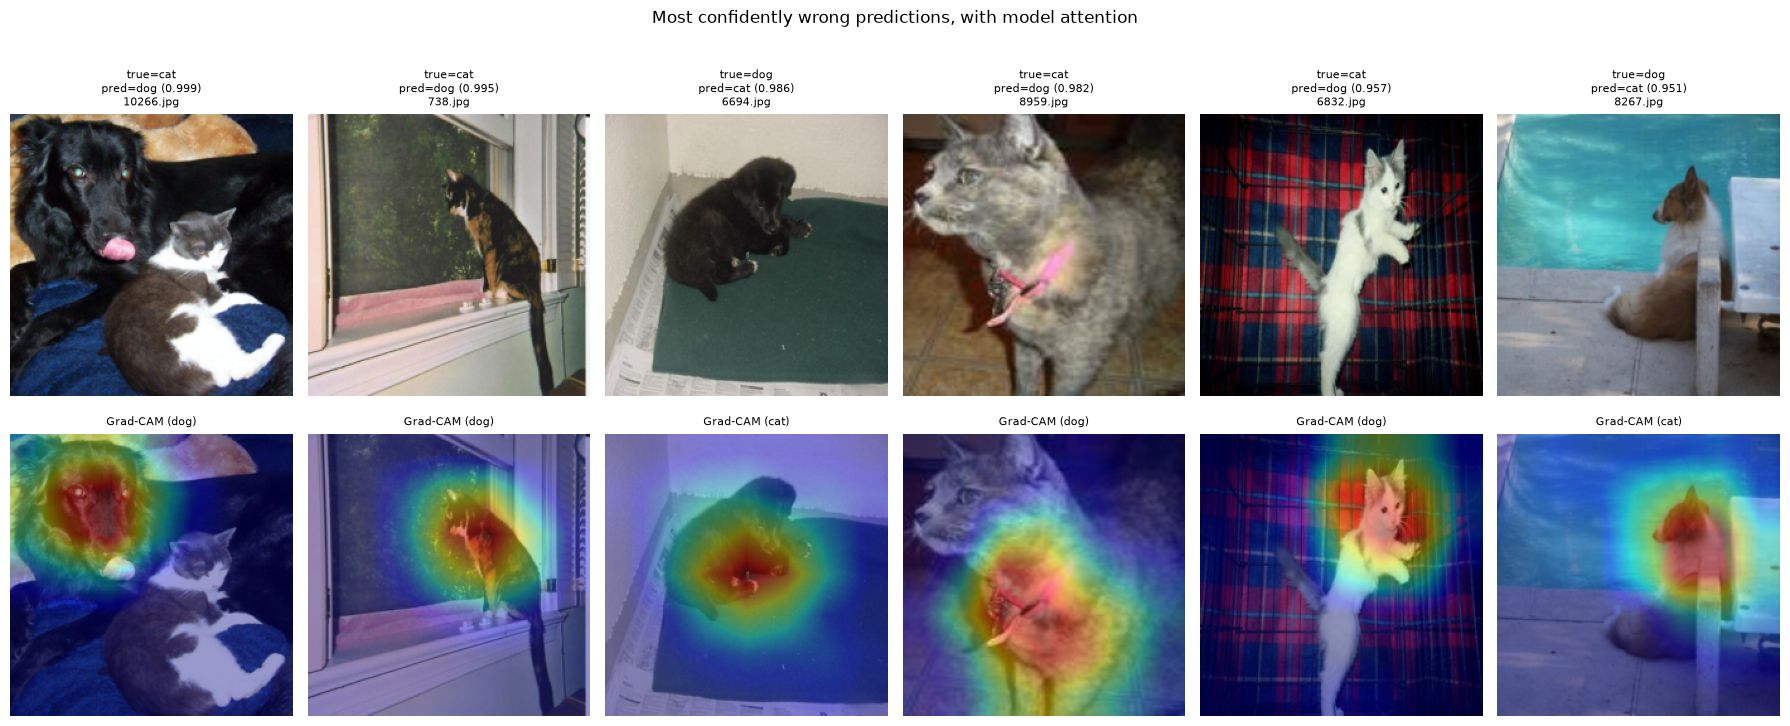

,file,true,predicted,confidence
0,10266.jpg,cat,dog,0.999048
1,738.jpg,cat,dog,0.995372
2,6694.jpg,dog,cat,0.986277
3,8959.jpg,cat,dog,0.982247
4,6832.jpg,cat,dog,0.957136
5,8267.jpg,dog,cat,0.950611


In [8]:
worst_idx = most_confident_errors(test_labels, probs, k=6)

fig, axes = plt.subplots(2, len(worst_idx), figsize=(3 * len(worst_idx), 7.4))
for col, idx in enumerate(worst_idx):
    image = test_dataset[idx][0].unsqueeze(0).to(device)
    display = to_display_image(image)
    # the map is taken for the class the model wrongly chose, so it answers
    # "what made it say this?" rather than "where was the correct evidence?"
    heatmap = cam(image, target_class=int(preds[idx]))

    axes[0, col].imshow(display)
    axes[0, col].set_title(
        f"true={CLASS_NAMES[test_labels[idx]]}\n"
        f"pred={CLASS_NAMES[preds[idx]]} ({probs[idx, preds[idx]]:.3f})\n"
        f"{test_paths[idx].name}",
        fontsize=8,
    )
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay_heatmap(display, heatmap))
    axes[1, col].set_title(f"Grad-CAM ({CLASS_NAMES[preds[idx]]})", fontsize=8)
    axes[1, col].axis("off")

fig.suptitle("Most confidently wrong predictions, with model attention")
# six columns leave each row short on height, so reserve room for the suptitle
# and open the gap between rows to keep every title clear of the images
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.subplots_adjust(hspace=0.10)
plt.savefig("../outputs/figures/misclassified_examples.png", dpi=150)
plt.show()

pd.DataFrame(
    {
        "file": [test_paths[i].name for i in worst_idx],
        "true": [CLASS_NAMES[test_labels[i]] for i in worst_idx],
        "predicted": [CLASS_NAMES[preds[i]] for i in worst_idx],
        "confidence": [probs[i, preds[i]] for i in worst_idx],
    }
)

### Discussion

Having the attention map under each of these six changes what can be said about them,
so it is worth going through the categories with the maps in hand.

**One is label noise, and the map settles it.** `10266.jpg` is labeled cat, and the
model called it dog at 0.999. The frame holds a black dog and a cat curled up
against it, with the dog taking most of the upper half of the shot, and the heat sits
squarely on the dog's face while the cat stays cold. The model was not
confused: it found a dog in an image labeled cat and said so. This is the clearest
possible demonstration that the file is an error only by convention, and it is the kind
of verdict the raw image alone could not deliver, since without the map the same
picture is equally consistent with the model having latched onto the cat and
blundered.

**Four are genuine ambiguity**, and in every one of them the heat lands on the animal:

* `738.jpg`: the cat sits small in frame on a backlit windowsill, and attention finds it correctly, then reads it as a dog anyway.
* `6694.jpg`: a black puppy curled on a mat, with heat centered on the curled body. A curled dark shape removes nearly every cue that separates the classes.
* `6832.jpg`: a white long-haired cat rearing on its hind legs, a pose well outside the usual distribution, with attention on the animal's upper body.
* `8267.jpg`: a dog photographed from behind with no face visible, and attention on the head and shoulders it can see.

In three of these the animal's face is absent, turned away, or too small to resolve.
That matches the correct-prediction maps above, where heat lands on the muzzle and eyes
every single time. The model is strongly face-driven, so photographs that deny it a
face are exactly where it fails, and the maps show it hunting in the right place and
coming up short.

**One is a real model weakness, and here the map is genuinely diagnostic.**
`8959.jpg` is a grey tabby in profile, unambiguously a cat, wearing a pink collar,
called dog at 0.982. Nothing about the image is hard for a human. The attention map
shows why: the heat sits on the chest and collar, and the cat's face is left in the
cold part of the map. The model classified this animal on the strength of a collar and
a raised-head profile, both far more common on dogs in this dataset, while declining to
look at the one region that would have settled it. That is a specific, nameable defect
rather than a shrug.

**The cross-cutting finding is what the six have in common.** In all of them attention
is on the animal. Not one is a case of the model reading the background. That is a
sharp contrast with the Grad-CAM panel on the first four errors above, where two of the
four show attention abandoning the animal for outdoor vegetation, leaf litter in one
and lawn grass in the other, with both of those images being cats called dogs.

The two groups differ in confidence, and the direction is informative. Every one of the
six most confident errors sits between 0.95 and 0.999, and every one looks at the
animal. The two background-shortcut cases sit at 0.55 and 0.80, below the whole
confident band, and one of them is barely past the decision boundary at all. On this
evidence the model has two distinct failure modes with distinct signatures: it misreads
animals it has genuinely examined, confidently, and it guesses from context when the
animal itself is not telling it much, tentatively. The sample is small enough that this
is a hypothesis rather than a measurement, but it is a testable one, and it is not a
hypothesis the accuracy number could have produced.

**The aggregate metrics conceal all of this.** The confusion matrix is nearly
symmetric, 24 cats read as dogs against 20 the other way, which reads as an unbiased
model. Yet four of the six most confident errors are cats called dogs, and both
background-shortcut failures are outdoor cats called dogs. There is a directional
failure mode; it is simply too small to move the summary statistics. A confusion matrix
can tell you the error rate is balanced without telling you the errors share a cause.

**What this implies for the ceiling.** At 98.82% test accuracy, 44 errors remain out of
3,744, and the maps suggest they are not all the same kind of thing. Some are
mislabeled or genuinely unresolvable, so buying accuracy with a larger backbone or a
longer schedule would be chasing noise. The two interventions the evidence actually
supports are narrower: break the background correlation with augmentation or with more
indoor dogs and outdoor cats, and address the model's willingness to decide on
accessories like collars rather than on the face. Neither is a conclusion the accuracy
number on its own could have suggested.

## Closing notes

The pipeline here is a fine-tuned ResNet18 reaching 98.82% accuracy on a held-out
test set that neither training nor checkpoint selection ever saw, evaluated past that
headline number in three ways: per-class metrics and a confusion matrix to check for
asymmetric bias, Grad-CAM to ask whether the model attends to the animal rather than
to background correlates, and a confidence-ranked error analysis to separate label
noise from genuine model weakness.

The Grad-CAM step is what turned a good score into a caveat. On correct predictions
attention lands on the animal's face; on a portion of the errors it lands on outdoor
vegetation instead, which is a shortcut the metrics alone would never have exposed.

That last distinction is the practical payoff. When a portion of the remaining error is
mislabeled or truly ambiguous data, the honest conclusion is that additional training or
a deeper backbone would chase noise, not signal, and knowing where that ceiling sits is
more useful than another decimal place of accuracy.